In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import os
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
for dirname, _, filenames in os.walk("D:\HCMUT\STUDY\252\p4aids\btl\ieee-fraud-detection"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
train_identity = pd.read_csv("ieee-fraud-detection/train_identity.csv")
train_transaction = pd.read_csv("ieee-fraud-detection/train_transaction.csv")

print(f"train_identity.shape= {train_identity.shape}")
print(f"train_transaction.shape= {train_transaction.shape}")

train_identity.shape= (144233, 41)
train_transaction.shape= (590540, 394)


In [4]:
train = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

print("Merged Train:", train.shape)


Merged Train: (590540, 434)


In [5]:
def plot_numerical_feature(df, feature_name, log_scale=False, bins=50):
    """
    Hàm vẽ 3 biểu đồ Histogram:
    1. Overall (Cột) + Fraud Rate 
    2. Not Fraud 
    3. Fraud 
    """
    print(f"--- Đang phân tích biến {feature_name} ---")
    
    temp_df = df[[feature_name, 'isFraud']].dropna().copy()
    
    # Áp dụng Log-transform nếu cần
    if log_scale:
        min_val = temp_df[feature_name].min()
        if min_val < 0:
            temp_df[feature_name] = np.log1p(temp_df[feature_name] - min_val)
        else:
            temp_df[feature_name] = np.log1p(temp_df[feature_name])
        
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
    text_color = 'black'

    # ==========================================
    # 2. TÍNH FRAUD RATE CHO TỪNG KHOẢNG 
    # ==========================================
    bin_edges = np.histogram_bin_edges(temp_df[feature_name], bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    temp_df['bin'] = pd.cut(temp_df[feature_name], bins=bin_edges, include_lowest=True)
    
    fraud_rate = temp_df.groupby('bin', observed=False)['isFraud'].mean() * 100

    # ==========================================
    # BIỂU ĐỒ 1: OVERALL DISTRIBUTION + FRAUD RATE LINE
    # ==========================================
    sns.histplot(
        data=temp_df, x=feature_name, kde=False, bins=bin_edges, 
        color="#2ca02c", alpha=0.5, stat="count", ax=axes[0]
    )
    axes[0].set_title(f'Overall Distribution', fontsize=14, fontweight='bold', color=text_color)
    axes[0].set_ylabel('Count', fontsize=12, color=text_color)
    
    ax1_twin = axes[0].twinx()
    ax1_twin.plot(bin_centers, fraud_rate.values, color='red', marker='.', linewidth=2, label='Fraud Rate')
    ax1_twin.set_ylabel('Fraud Rate (%)', fontsize=12, color='red')
    
    max_fraud = fraud_rate.max()
    if pd.isna(max_fraud):
        ax1_twin.set_ylim(0, 15)
    else:
        ax1_twin.set_ylim(0, max_fraud + (max_fraud * 0.2) + 1)
        
    ax1_twin.legend(loc='upper right')

    # ==========================================
    # BIỂU ĐỒ 2: NOT FRAUD (isFraud == 0)
    # ==========================================
    sns.histplot(
        data=temp_df[temp_df['isFraud'] == 0], x=feature_name, kde=False, bins=bin_edges, 
        color="#1f77b4", alpha=0.5, stat="count", ax=axes[1]
    )
    axes[1].set_title(f'Not Fraud (isFraud = 0)', fontsize=14, fontweight='bold', color=text_color)
    axes[1].set_ylabel('Count', fontsize=12, color=text_color)

    # ==========================================
    # BIỂU ĐỒ 3: FRAUD (isFraud == 1)
    # ==========================================
    sns.histplot(
        data=temp_df[temp_df['isFraud'] == 1], x=feature_name, kde=False, bins=bin_edges, 
        color="#d62728", alpha=0.5, stat="count", ax=axes[2]
    )
    axes[2].set_title(f'Fraud (isFraud = 1)', fontsize=14, fontweight='bold', color=text_color)
    axes[2].set_ylabel('Count', fontsize=12, color=text_color)

    for ax in axes:
        ax.set_xlabel(feature_name, fontsize=12, color=text_color)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [6]:
# Code rà soát và tạo các nhóm V-features có chung số lượng Missing Value
v_cols = [f'V{i}' for i in range(1, 340)]

nan_groups = {}
for col in v_cols:
    if col in train.columns:
        nan_count = train[col].isnull().sum()
        if nan_count not in nan_groups:
            nan_groups[nan_count] = []
        nan_groups[nan_count].append(col)

# In kết quả để xem các nhóm
for count, cols in nan_groups.items():
    print(f"Nhóm có {count} NaN gồm {len(cols)} biến: {cols}")

Nhóm có 279287 NaN gồm 11 biến: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11']
Nhóm có 76073 NaN gồm 23 biến: ['V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34']
Nhóm có 168969 NaN gồm 18 biến: ['V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52']
Nhóm có 77096 NaN gồm 22 biến: ['V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74']
Nhóm có 89164 NaN gồm 20 biến: ['V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94']
Nhóm có 314 NaN gồm 43 biến: ['V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V11

In [7]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Thiết lập phong cách cho biểu đồ
# sns.set(style="white")

# # Duyệt qua các nhóm đã tìm được
# for i, (nan_count, block_cols) in enumerate(nan_groups.items()):
    
#     # Chỉ vẽ nếu block có từ 2 biến trở lên (để có sự tương quan)
#     # Và giới hạn vẽ các block quan trọng (ví dụ block có nhiều biến) để tránh tràn màn hình
#     if len(block_cols) > 1:
        
#         # Tính ma trận tương quan
#         corr = train[block_cols].corr()
        
        
#         # Khởi tạo figure
#         plt.figure(figsize=(max(6, len(block_cols)*0.8), max(5, len(block_cols)*0.6)))
        
#         # Vẽ Heatmap
#         sns.heatmap(corr, 
#                     cmap='RdBu_r', # Màu đỏ là tương quan thuận, xanh là tương quan nghịch
#                     annot=True, # Hiện số nếu số biến ít
#                     fmt=".2f",
#                     center=0,
#                     linewidths=.5, 
#                     cbar_kws={"shrink": .5})
        
#         plt.title(f"Block {i}: {len(block_cols)} biến (NaN count: {nan_count})", fontsize=15, fontweight='bold')
#         plt.show()
#     else:
#         print(f"Block {i} chỉ có 1 biến ({block_cols[0]}), bỏ qua bước vẽ ma trận.")

In [8]:
import pandas as pd
import numpy as np

def filter_v_cols_by_nunique(df, v_blocks, threshold=0.9):
    """
    Hàm lọc đa cộng tuyến cho từng block V-features.
    Giữ lại biến có nunique cao nhất nếu độ tương quan vượt ngưỡng threshold.
    
    Parameters:
    - df: DataFrame chứa dữ liệu
    - v_blocks: List chứa tên các cột trong 1 block (VD: ['V1', 'V2', 'V3'])
    - threshold: Ngưỡng tương quan (mặc định 0.9)
    
    Returns:
    - cols_to_keep: Danh sách các cột được giữ lại
    - cols_to_drop: Danh sách các cột bị loại
    """
    
    # 1. Tính số lượng unique values cho tất cả các biến trong block
    # Sắp xếp giảm dần: Biến nào có nhiều unique nhất sẽ nằm trên cùng để ưu tiên xét trước
    unique_counts = df[v_blocks].nunique().sort_values(ascending=False)
    sorted_cols = unique_counts.index.tolist()
    
    # 2. Tính ma trận tương quan tuyệt đối
    # Dùng abs() để bắt cả các trường hợp tương quan nghịch (VD: -0.95)
    corr_matrix = df[v_blocks].corr().abs()
    
    cols_to_drop = set()
    cols_to_keep = []
    
    # 3. Duyệt qua từng biến theo thứ tự ưu tiên (từ nunique cao -> thấp)
    for col in sorted_cols:
        # Nếu biến này đã bị đánh dấu loại bỏ từ các vòng lặp trước thì bỏ qua
        if col in cols_to_drop:
            continue
            
        # Nếu chưa bị loại, đây là biến tốt nhất hiện tại -> Giữ lại
        cols_to_keep.append(col)
        
        # 4. Tìm tất cả các biến có tương quan > threshold với biến đang giữ
        # và đưa chúng vào danh sách "trảm" (drop)
        highly_correlated = corr_matrix.index[corr_matrix[col] > threshold].tolist()
        for corr_col in highly_correlated:
            if corr_col != col:  # Không tự loại chính bản thân nó
                cols_to_drop.add(corr_col)
                
    return cols_to_keep, list(cols_to_drop)

In [9]:
final_v_cols_to_keep = []
final_v_cols_to_drop = []

# Duyệt qua từng nhóm block V
for nan_count, block_cols in nan_groups.items():
    
    # Chỉ tính toán nếu block có nhiều hơn 1 biến
    if len(block_cols) > 1:
        keep, drop = filter_v_cols_by_nunique(train, block_cols, threshold=0.9)
        final_v_cols_to_keep.extend(keep)
        final_v_cols_to_drop.extend(drop)
    else:
        # Nếu block chỉ có 1 biến thì dĩ nhiên giữ lại
        final_v_cols_to_keep.extend(block_cols)

print("=========================================")
print(f"Tổng số biến V ban đầu: {len(final_v_cols_to_keep) + len(final_v_cols_to_drop)}")
print(f"Tổng số biến V được giữ lại: {len(final_v_cols_to_keep)}")
print(final_v_cols_to_keep)
print(f"Tổng số biến V bị loại bỏ: {len(final_v_cols_to_drop)}")

Tổng số biến V ban đầu: 339
Tổng số biến V được giữ lại: 207
['V3', 'V6', 'V7', 'V2', 'V8', 'V9', 'V4', 'V11', 'V1', 'V17', 'V20', 'V32', 'V23', 'V24', 'V26', 'V34', 'V30', 'V13', 'V25', 'V27', 'V14', 'V37', 'V38', 'V44', 'V40', 'V43', 'V47', 'V52', 'V46', 'V36', 'V48', 'V50', 'V41', 'V56', 'V55', 'V59', 'V58', 'V62', 'V74', 'V67', 'V66', 'V64', 'V54', 'V70', 'V61', 'V68', 'V65', 'V78', 'V77', 'V86', 'V87', 'V80', 'V85', 'V79', 'V82', 'V83', 'V92', 'V91', 'V76', 'V89', 'V88', 'V127', 'V130', 'V136', 'V131', 'V135', 'V129', 'V99', 'V106', 'V100', 'V125', 'V123', 'V124', 'V98', 'V113', 'V112', 'V110', 'V109', 'V108', 'V115', 'V114', 'V116', 'V122', 'V121', 'V120', 'V119', 'V118', 'V117', 'V107', 'V162', 'V161', 'V140', 'V147', 'V155', 'V158', 'V138', 'V142', 'V141', 'V160', 'V159', 'V165', 'V164', 'V166', 'V152', 'V203', 'V202', 'V207', 'V215', 'V216', 'V205', 'V206', 'V187', 'V176', 'V199', 'V183', 'V186', 'V172', 'V191', 'V173', 'V209', 'V210', 'V208', 'V180', 'V171', 'V201', 'V170', '

In [10]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Lấy danh sách các biến V còn lại sau khi lọc
# v_cols_remaining = [col for col in final_v_cols_to_keep if col.startswith('V')]

# # Tính ma trận tương quan
# corr_remaining = train[v_cols_remaining].corr()

# # Vẽ Heatmap tổng quát
# plt.figure(figsize=(20, 15))
# sns.heatmap(corr_remaining, 
#             cmap='RdBu_r', 
#             center=0, 
#             annot=False, # Không hiện số vì quá nhiều biến
#             cbar_kws={"shrink": .8})

# plt.title(f"Correlation Matrix of {len(v_cols_remaining)} Remaining V-Features", fontsize=16, fontweight='bold')
# plt.show()

In [11]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Lấy toàn bộ 339 biến V ban đầu (hoặc 207 biến còn lại sau khi lọc)
v_cols = final_v_cols_to_keep

X = train[v_cols]
y = train['isFraud']

# Chia dữ liệu để train nhanh (chỉ cần 20-30% dữ liệu là đủ để thấy Importance)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tạo Dataset cho LightGBM
dtrain = lgb.Dataset(X_train, label=y_train)
dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[498]	training's auc: 0.91352	valid_1's auc: 0.888583


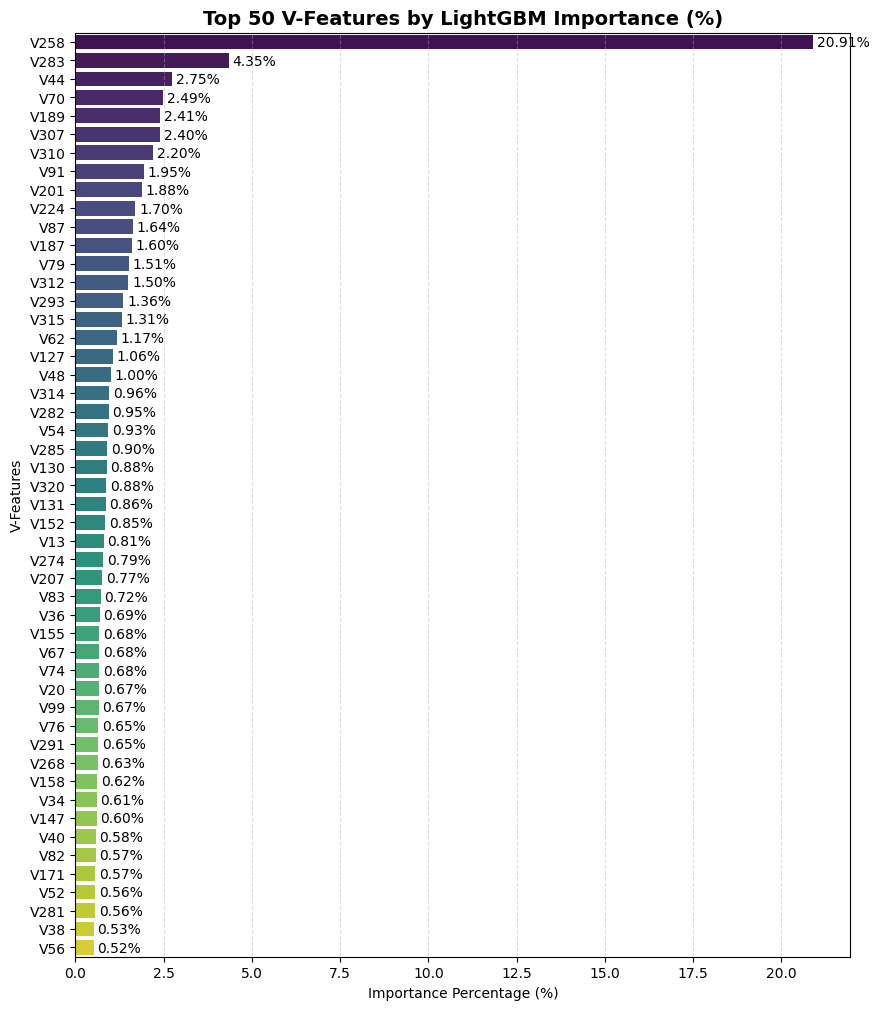

Top 10 biến quan trọng nhất chiếm: 43.03% tổng thông tin.
Top 50 biến quan trọng nhất chiếm: 77.22% tổng thông tin.


In [12]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'random_state': 42
}

# Train mô hình
model = lgb.train(
    params,
    dtrain,
    num_boost_round=500,
    valid_sets=[dtrain, dval],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# Trích xuất Importance
importance_df = pd.DataFrame({
    'feature': v_cols,
    'importance': model.feature_importance(importance_type='gain') # Dùng 'gain' để đo đóng góp vào độ chính xác
}).sort_values(by='importance', ascending=False)

# 1. Tính tổng Gain của tất cả các biến
total_gain = importance_df['importance'].sum()

# 2. Tạo cột Percentage (%)
importance_df['importance_pct'] = (importance_df['importance'] / total_gain) * 100

# 3. Tính thêm cột Tích lũy (Cumulative %) - rất hữu ích để quyết định điểm cắt (Cut-off)
importance_df['cumulative_pct'] = importance_df['importance_pct'].cumsum()

# Vẽ biểu đồ Top 50 biến theo %
plt.figure(figsize=(10, 12))
sns.barplot(x='importance_pct', y='feature', data=importance_df.head(50), palette='viridis')

# Thêm nhãn % vào cuối mỗi thanh bar cho dễ nhìn
for i, v in enumerate(importance_df['importance_pct'].head(50)):
    plt.text(v + 0.1, i + .25, f'{v:.2f}%', color='black', fontsize=10)

plt.title('Top 50 V-Features by LightGBM Importance (%)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Percentage (%)')
plt.ylabel('V-Features')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

# In ra thông tin thống kê
print(f"Top 10 biến quan trọng nhất chiếm: {importance_df['importance_pct'].head(10).sum():.2f}% tổng thông tin.")
print(f"Top 50 biến quan trọng nhất chiếm: {importance_df['importance_pct'].head(50).sum():.2f}% tổng thông tin.")

In [16]:
# Giữ lại những biến đóng góp vào 95% tổng Gain đầu tiên
v_cols_to_keep = importance_df[importance_df['cumulative_pct'] <= 99]['feature'].tolist()
v_cols_to_drop = [c for c in v_cols if c not in v_cols_to_keep]

print(f"Số biến V cần thiết để giữ lại 99% thông tin: {len(v_cols_to_keep)}")

Số biến V cần thiết để giữ lại 99% thông tin: 151
